# ANN benchmark 

In [279]:
# install 
%pip install numpy tensorflow matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [280]:
# imports

import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
import matplotlib.pyplot as plt

In [281]:
# hyper paramaters

BATCH_SIZE = 30024
EPOCHS = 10
VERBOSE = 1
OPTIMIZER = Adam(0.0005)
NB_CLASSES = 1

# Model defintion:

In [282]:
def create_model(input_shape):
    # model = Sequential()
    
    # model.add(layers.Dense(64, input_shape=(input_shape,)))
    # model.add(layers.BatchNormalization())  # Normalize activations
    # model.add(layers.Activation('relu'))

    # model.add(layers.Dense(128))
    # model.add(layers.BatchNormalization())
    # model.add(layers.Activation('relu'))

    # model.add(layers.Dense(32))
    # model.add(layers.BatchNormalization())
    # model.add(layers.Activation('relu'))

    # model.add(layers.Dense(NB_CLASSES, activation='sigmoid'))  # Output layer

    model = Sequential([
        layers.Dense(512, input_shape=(input_shape,)),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(512),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64),
        layers.BatchNormalization(),
        
        layers.Dense(NB_CLASSES, activation='sigmoid')
    ])

    return model

# Load datasets

In [283]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


df_chall = pd.read_csv('../datasets/challenger_dataset.csv')
df_grandMaster = pd.read_csv('../datasets/grandmaster_dataset.csv')
df_master = pd.read_csv('../datasets/master_dataset.csv')

df = pd.concat([df_chall, df_grandMaster, df_master])

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

df.fillna(df.median(), inplace=True)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

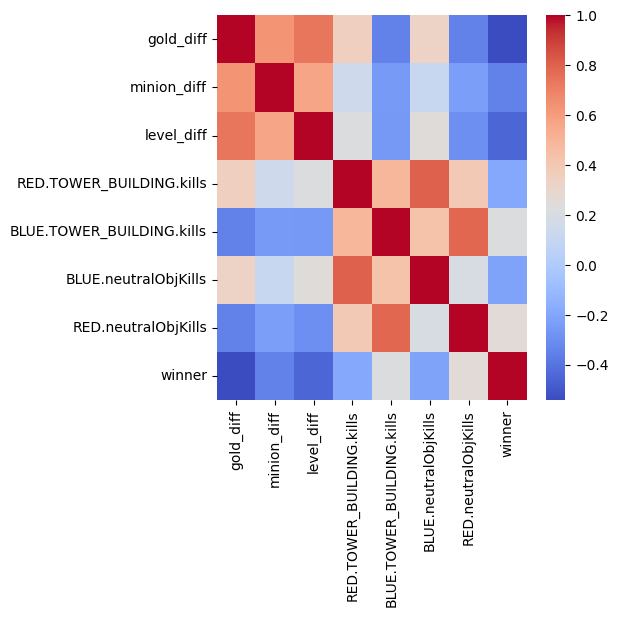

In [284]:
#trying to modify the dataset 
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf["BLUE.neutralObjKills"] = df["BLUE.HEXTECH_DRAGON.kills"] + df["BLUE.WATER_DRAGON.kills"] + \
                                df["BLUE.FIRE_DRAGON.kills"] + df["BLUE.EARTH_DRAGON.kills"] + \
                                df["BLUE.AIR_DRAGON.kills"] + df["BLUE.ELDER_DRAGON.kills"] + \
                                df["BLUE.RIFTHERALD.kills"] + df["BLUE.BARON_NASHOR.kills"] + \
                                df["BLUE.ATAKHAN.kills"] + df["BLUE.CHEMTECH_DRAGON.kills"] + \
                                df["BLUE.HORDE.kills"]

tdf["RED.neutralObjKills"] = df["RED.HEXTECH_DRAGON.kills"] + df["RED.WATER_DRAGON.kills"] + \
                                df["RED.FIRE_DRAGON.kills"] + df["RED.EARTH_DRAGON.kills"] + \
                                df["RED.AIR_DRAGON.kills"] + df["RED.ELDER_DRAGON.kills"] + \
                                df["RED.RIFTHERALD.kills"] + df["RED.BARON_NASHOR.kills"] + \
                                df["RED.ATAKHAN.kills"] + df["RED.CHEMTECH_DRAGON.kills"] + \
                                df["RED.HORDE.kills"]
tdf['winner'] = df['winner']

correlationMat = tdf.corr()

# Set the size of the plot
plt.figure(figsize=(5, 5))

# Create a heatmap of the correlation matrix
sns.heatmap(correlationMat, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

In [285]:
# split the dataset into training and testing
from sklearn.model_selection import train_test_split

X = tdf.drop('winner', axis=1)
y = tdf['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4840955, 7) (1210239, 7) (4840955,) (1210239,)


# Train the model

In [286]:
# create the model
model = create_model(len(X.columns))
model.compile(optimizer=OPTIMIZER, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/Users/simonbandiera/Documents/kent/AiSysImplementation/LeagueOfLegendsModelBenchmark/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/simonbandiera/Documents/kent/AiSysImplementation/LeagueOfLegendsModelBenchmark/.venv/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_140 (Dense)               │ (None, 512)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_141 (Dense)               │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_142 (Dense)               │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_143 (Dense)               │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_144 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,095,553 (4.18 MB)

 Trainable params: 1,091,329 (4.16 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [287]:
# train the model
history = model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, verbose=VERBOSE, validation_split=0.2)

# evaluate the model
score = model.evaluate(X_test, y_test, verbose=VERBOSE)
print("Test score:", score[0])
print("Test accuracy:", score[1])

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.6971 - loss: 0.5887 - val_accuracy: 0.7231 - val_loss: 0.6379
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.7375 - loss: 0.4998 - val_accuracy: 0.7275 - val_loss: 0.6086
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.7399 - loss: 0.4960 - val_accuracy: 0.7391 - val_loss: 0.5651
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.7407 - loss: 0.4947 - val_accuracy: 0.7429 - val_loss: 0.5262
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.7413 - loss: 0.4938 - val_accuracy: 0.7426 - val_loss: 0.4991
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.7407 - loss: 0.4937 - val_accuracy: 0.7430 - val_loss: 0.4915
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.7414 - loss: 0.4935 - val_accuracy: 0.7426 - val_loss: 0.4911
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.7414 - loss: 0.4934 - val_acc